In [1]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns



# Libraries and packages for text (pre-)processing 
import string
import re
import nltk

In [2]:
train = pd.read_csv('./train_clean.csv')
test = pd.read_csv('./test_clean.csv')
subm = pd.read_csv('./sample_submission.csv')
display(train.shape, train.head())

(159571, 9)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_text_clean
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation\nwhy the edits made under my usern...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww he matches this background colour i am se...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man i am really not trying to edit war it ...
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,\nmore\ni cannot make any real suggestions on ...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,you sir are my hero any chance you remember wh...


# Tokenization

In [8]:
# Tokenizing the tweet base texts.
from nltk.tokenize import word_tokenize

train['tokenized'] = train['comment_text_clean'].apply(str).apply(word_tokenize)
test['tokenized'] = test['comment_text_clean'].apply(str).apply(word_tokenize)
train['tokenized'].head()

0    [explanation, why, the, edits, made, under, my...
1    [daww, he, matches, this, background, colour, ...
2    [hey, man, i, am, really, not, trying, to, edi...
3    [more, i, can, not, make, any, real, suggestio...
4    [you, sir, are, my, hero, any, chance, you, re...
Name: tokenized, dtype: object

**Remove Stop Words (or/and Frequent words/ Rare words):**

Stop words are common words in any language that occur with a high frequency but do not deliver meaningful information for the whole sentence. For example, {“a”, “about”, “above”, “across”, “after”, “afterward”, “again”, ...} can be considered as stop words. Traditionally, we could remove all of them in the text preprocessing stage. However, refer to the example from the Natural Language Processing in Action book:

```txt

        Mark reported to the CEO
        Suzanne reported as the CEO to the board

    In your NLP pipeline, you might create 4-grams such as reported to the CEO and reported as the CEO. If you remove the stop words from the 4-grams, both examples would be reduced to "reported CEO", and you would lack the information about the professional hierarchy. In the first example, Mark could have been an assistant to the CEO, whereas in the second example Suzanne was the CEO reporting to the board. Unfortunately, retaining the stop words within your pipeline creates another problem: it increases the length of the n-grams required to make use of these connections formed by the otherwise meaningless stop words. This issue forces us to retain at least 4-grams if you want to avoid the ambiguity of the human resources example. Designing a filter for stop words depends on your particular application.

```

In short, removing stop words is a common method in NLP text preprocessing, whereas, it needs to be experimented carefully depending on different situations.

In [9]:
# Removing stopwords.
from nltk.corpus import stopwords

stop = set(stopwords.words('english'))
train['stopwords_removed'] = train['tokenized'].apply(lambda x: [word for word in x if word not in stop])
test['stopwords_removed'] = test['tokenized'].apply(lambda x: [word for word in x if word not in stop])

train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_text_clean,tokenized,stopwords_removed
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation\nwhy the edits made under my usern...,"[explanation, why, the, edits, made, under, my...","[explanation, edits, made, username, hardcore,..."
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww he matches this background colour i am se...,"[daww, he, matches, this, background, colour, ...","[daww, matches, background, colour, seemingly,..."
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man i am really not trying to edit war it ...,"[hey, man, i, am, really, not, trying, to, edi...","[hey, man, really, trying, edit, war, guy, con..."
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,\nmore\ni cannot make any real suggestions on ...,"[more, i, can, not, make, any, real, suggestio...","[make, real, suggestions, improvement, wondere..."
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,you sir are my hero any chance you remember wh...,"[you, sir, are, my, hero, any, chance, you, re...","[sir, hero, chance, remember, page]"


### Stemming

Stemming is a process of extracting a root word - identifying a common stem among various forms (e.g., singular and plural noun form) of a word, for example, the words "gardening", "gardener" or "gardens" share the same stem, garden. Stemming uproots suffixes from words to merge words with similar meanings under their standard stem.

There are three major stemming algorithms in use nowadays:

- Porter - PorterStemmer()): This stemming algorithm is an older one. It’s from the 1980s and its main concern is removing the common endings to words so that they can be resolved to a common form. It’s not too complex and development on it is frozen. Typically, it’s a nice starting basic stemmer, but it’s not really advised to use it for any production/complex application. Instead, it has its place in research as a nice, basic stemming algorithm that can guarantee reproducibility. It also is a very gentle stemming algorithm when compared to others.

- Snowball - LancasterStemmer(): This algorithm is also known as the Porter2 stemming algorithm. It is almost universally accepted as better than the Porter stemmer, even being acknowledged as such by the individual who created the Porter stemmer. That being said, it is also more aggressive than the Porter stemmer. A lot of the things added to the Snowball stemmer were because of issues noticed with the Porter stemmer. There is about a 5% difference in the way that Snowball stems versus Porter.

- Lancaster - SnowballStemmer(): Just for fun, the Lancaster stemming algorithm is another algorithm that you can use. This one is the most aggressive stemming algorithm of the bunch. However, if you use the stemmer in NLTK, you can add your own custom rules to this algorithm very easily. It’s a good choice for that. One complaint around this stemming algorithm though is that it sometimes is overly aggressive and can really transform words into strange stems. Just make sure it does what you want it to before you go with this option!


**PorterStemmer**

In [6]:
from nltk.stem import PorterStemmer

def porter_stemmer(text):
    """
        Stem words in list of tokenized words with PorterStemmer
    """
    stemmer = nltk.PorterStemmer()
    stems = [stemmer.stem(i) for i in text]
    return stems


train['porter_stemmer'] = train['stopwords_removed'].apply(lambda x: porter_stemmer(x))
test['porter_stemmer'] = test['stopwords_removed'].apply(lambda x: porter_stemmer(x))


RecursionError: maximum recursion depth exceeded in comparison

**SnowballStemmer**

In [ ]:
from nltk.stem import SnowballStemmer

def snowball_stemmer(text):
    """
        Stem words in list of tokenized words with SnowballStemmer
    """
    stemmer = nltk.SnowballStemmer("english")
    stems = [stemmer.stem(i) for i in text]
    return stems

train['snowball_stemmer'] = train['stopwords_removed'].apply(lambda x: snowball_stemmer(x))
test['snowball_stemmer'] = test['stopwords_removed'].apply(lambda x: snowball_stemmer(x))

**LancasterStemmer**

In [ ]:
from nltk.stem import LancasterStemmer

def lancaster_stemmer(text):
    """
        Stem words in list of tokenized words with LancasterStemmer
    """
    stemmer = nltk.LancasterStemmer()
    stems = [stemmer.stem(i) for i in text]
    return stems


train['lancaster_stemmer'] = train['stopwords_removed'].apply(lambda x: lancaster_stemmer(x))
test['lancaster_stemmer'] = test['stopwords_removed'].apply(lambda x: lancaster_stemmer(x))

### Part of Speech Tagging (POS Tagging):¶


Part of speech tagging (POS tagging) distinguishes the part of speech (noun, verb, adjective, and etc.) of each word in the text. This is the critical stage for many NLP applications since, by identifying the POS of a word, we can infer its contextual meaning. The NLTK packages offer different POS Tagging algorithms, and in this notebook, we use the combination version of them.

- pos_tag/ DefaultTagger
- UnigramTagger
- BigramTagger
- Could also be a combination of the bigram tagger, unigram tagger, and default tagger 

In [10]:
from nltk.corpus import wordnet
from nltk.corpus import brown

# nltk.download('brown')

# You may also need the WordNet corpus if using POS tagging
# nltk.download('wordnet')
# nltk.download('omw-1.4')  # optional, for multilingual WordNet

wordnet_map = {"N":wordnet.NOUN, 
               "V":wordnet.VERB, 
               "J":wordnet.ADJ, 
               "R":wordnet.ADV
              }
    
train_sents = brown.tagged_sents(categories='news')
t0 = nltk.DefaultTagger('NN')
t1 = nltk.UnigramTagger(train_sents, backoff=t0)
t2 = nltk.BigramTagger(train_sents, backoff=t1)

def pos_tag_wordnet(text, pos_tag_type="pos_tag"):
    """
        Create pos_tag with wordnet format
    """
    pos_tagged_text = t2.tag(text)
    
    # map the pos tagging output with wordnet output 
    pos_tagged_text = [(word, wordnet_map.get(pos_tag[0])) if pos_tag[0] in wordnet_map.keys() else (word, wordnet.NOUN) for (word, pos_tag) in pos_tagged_text ]
    return pos_tagged_text

# pos_tag_wordnet(train['stopwords_removed'][2])

train['combined_postag_wnet'] = train['stopwords_removed'].apply(lambda x: pos_tag_wordnet(x))
test['combined_postag_wnet'] = test['stopwords_removed'].apply(lambda x: pos_tag_wordnet(x))

### Lemmatization

```txt
    Lemmatization is the task of determining that two words have the same root, despite their surface differences. The words am, are, and is have the shared lemma be; the words dinner and dinners both have the lemma dinner. Lemmatizing each of these forms to the same lemma will let us ﬁnd all mentions of words in Russian like Moscow. The lemmatized form of a sentence like He is reading detective stories would thus be He be read detective story.
```

```txt
    Some lemmatizers use the word’s part of speech (POS) tag in addition to its spelling to help improve accuracy. The POS tag for a word indicates its role in the grammar of a phrase or sentence. For example, the noun POS is for words that refer to “people, places, or things” within a phrase. An adjective POS is for a word that modifies or describes a noun. A verb refers to an action. The POS of a word in isolation cannot be determined. The context of a word must be known for its POS to be identified. So some advanced lemmatizers can’t be run-on words in isolation.

```

For example, the "good", "better" or "best" is lemmatized into good and the verb "gardening" should be lemmatized to "to garden", while the "garden" and "gardener" are both different lemmas. In this notebook, we will also explore on both lemmatize on without POS-Tagging and POS-Tagging examples.

In [11]:
from nltk.stem import WordNetLemmatizer

def lemmatize_word(text):
    """
        Lemmatize the tokenized words
    """

    lemmatizer = WordNetLemmatizer()
    lemma = [lemmatizer.lemmatize(word, tag) for word, tag in text]
    return lemma

**Lemmatization without POS Tagging:**

In [12]:
# Test without POS Tagging
lemmatizer = WordNetLemmatizer()

train['lemmatize_word_wo_pos'] = train['stopwords_removed'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
train['lemmatize_word_wo_pos'] = train['lemmatize_word_wo_pos'].apply(lambda x: [word for word in x if word not in stop])

test['lemmatize_word_wo_pos'] = test['stopwords_removed'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
test['lemmatize_word_wo_pos'] = test['lemmatize_word_wo_pos'].apply(lambda x: [word for word in x if word not in stop])
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_text_clean,tokenized,stopwords_removed,combined_postag_wnet,lemmatize_word_wo_pos
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation\nwhy the edits made under my usern...,"[explanation, why, the, edits, made, under, my...","[explanation, edits, made, username, hardcore,...","[(explanation, n), (edits, n), (made, v), (use...","[explanation, edits, made, username, hardcore,..."
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww he matches this background colour i am se...,"[daww, he, matches, this, background, colour, ...","[daww, matches, background, colour, seemingly,...","[(daww, n), (matches, n), (background, n), (co...","[daww, match, background, colour, seemingly, s..."
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man i am really not trying to edit war it ...,"[hey, man, i, am, really, not, trying, to, edi...","[hey, man, really, trying, edit, war, guy, con...","[(hey, n), (man, n), (really, r), (trying, v),...","[hey, man, really, trying, edit, war, guy, con..."
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,\nmore\ni cannot make any real suggestions on ...,"[more, i, can, not, make, any, real, suggestio...","[make, real, suggestions, improvement, wondere...","[(make, v), (real, a), (suggestions, n), (impr...","[make, real, suggestion, improvement, wondered..."
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,you sir are my hero any chance you remember wh...,"[you, sir, are, my, hero, any, chance, you, re...","[sir, hero, chance, remember, page]","[(sir, n), (hero, n), (chance, n), (remember, ...","[sir, hero, chance, remember, page]"


In [13]:


print(train["combined_postag_wnet"][8])
print(train["lemmatize_word_wo_pos"][8])



[('sorry', 'a'), ('word', 'n'), ('nonsense', 'n'), ('offensive', 'a'), ('anyway', 'r'), ('intending', 'n'), ('write', 'v'), ('anything', 'n'), ('articlewow', 'n'), ('would', 'n'), ('jump', 'v'), ('vandalism', 'n'), ('merely', 'r'), ('requesting', 'v'), ('encyclopedic', 'n'), ('one', 'n'), ('use', 'v'), ('school', 'n'), ('reference', 'n'), ('selective', 'n'), ('breeding', 'n'), ('page', 'n'), ('almost', 'r'), ('stub', 'n'), ('points', 'n'), ('animal', 'n'), ('breeding', 'n'), ('short', 'a'), ('messy', 'n'), ('article', 'n'), ('gives', 'v'), ('info', 'n'), ('must', 'n'), ('someone', 'n'), ('around', 'r'), ('expertise', 'n'), ('eugenics', 'n'), ('93161107169', 'n')]
['sorry', 'word', 'nonsense', 'offensive', 'anyway', 'intending', 'write', 'anything', 'articlewow', 'would', 'jump', 'vandalism', 'merely', 'requesting', 'encyclopedic', 'one', 'use', 'school', 'reference', 'selective', 'breeding', 'page', 'almost', 'stub', 'point', 'animal', 'breeding', 'short', 'messy', 'article', 'give', '

**Lemmatization with POS Tagging:**

In [14]:
# Test with POS Tagging
lemmatizer = WordNetLemmatizer()

train['lemmatize_word_w_pos'] = train['combined_postag_wnet'].apply(lambda x: lemmatize_word(x))
train['lemmatize_word_w_pos'] = train['lemmatize_word_w_pos'].apply(lambda x: [word for word in x if word not in stop]) # double check to remove stop words
train['lemmatize_text'] = [' '.join(map(str, l)) for l in train['lemmatize_word_w_pos']] # join back to text


test['lemmatize_word_w_pos'] = test['combined_postag_wnet'].apply(lambda x: lemmatize_word(x))
test['lemmatize_word_w_pos'] = test['lemmatize_word_w_pos'].apply(lambda x: [word for word in x if word not in stop]) # double check to remove stop words
test['lemmatize_text'] = [' '.join(map(str, l)) for l in test['lemmatize_word_w_pos']] # join back to text

train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_text_clean,tokenized,stopwords_removed,combined_postag_wnet,lemmatize_word_wo_pos,lemmatize_word_w_pos,lemmatize_text
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation\nwhy the edits made under my usern...,"[explanation, why, the, edits, made, under, my...","[explanation, edits, made, username, hardcore,...","[(explanation, n), (edits, n), (made, v), (use...","[explanation, edits, made, username, hardcore,...","[explanation, edits, make, username, hardcore,...",explanation edits make username hardcore metal...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww he matches this background colour i am se...,"[daww, he, matches, this, background, colour, ...","[daww, matches, background, colour, seemingly,...","[(daww, n), (matches, n), (background, n), (co...","[daww, match, background, colour, seemingly, s...","[daww, match, background, colour, seemingly, s...",daww match background colour seemingly stick t...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man i am really not trying to edit war it ...,"[hey, man, i, am, really, not, trying, to, edi...","[hey, man, really, trying, edit, war, guy, con...","[(hey, n), (man, n), (really, r), (trying, v),...","[hey, man, really, trying, edit, war, guy, con...","[hey, man, really, try, edit, war, guy, consta...",hey man really try edit war guy constantly rem...
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,\nmore\ni cannot make any real suggestions on ...,"[more, i, can, not, make, any, real, suggestio...","[make, real, suggestions, improvement, wondere...","[(make, v), (real, a), (suggestions, n), (impr...","[make, real, suggestion, improvement, wondered...","[make, real, suggestion, improvement, wondered...",make real suggestion improvement wondered sect...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,you sir are my hero any chance you remember wh...,"[you, sir, are, my, hero, any, chance, you, re...","[sir, hero, chance, remember, page]","[(sir, n), (hero, n), (chance, n), (remember, ...","[sir, hero, chance, remember, page]","[sir, hero, chance, remember, page]",sir hero chance remember page


In [15]:


print(train["comment_text"][8])
print(train["combined_postag_wnet"][8])
print(train["lemmatize_word_wo_pos"][8])
print(train["lemmatize_word_w_pos"][8])



Sorry if the word 'nonsense' was offensive to you. Anyway, I'm not intending to write anything in the article(wow they would jump on me for vandalism), I'm merely requesting that it be more encyclopedic so one can use it for school as a reference. I have been to the selective breeding page but it's almost a stub. It points to 'animal breeding' which is a short messy article that gives you no info. There must be someone around with expertise in eugenics? 93.161.107.169
[('sorry', 'a'), ('word', 'n'), ('nonsense', 'n'), ('offensive', 'a'), ('anyway', 'r'), ('intending', 'n'), ('write', 'v'), ('anything', 'n'), ('articlewow', 'n'), ('would', 'n'), ('jump', 'v'), ('vandalism', 'n'), ('merely', 'r'), ('requesting', 'v'), ('encyclopedic', 'n'), ('one', 'n'), ('use', 'v'), ('school', 'n'), ('reference', 'n'), ('selective', 'n'), ('breeding', 'n'), ('page', 'n'), ('almost', 'r'), ('stub', 'n'), ('points', 'n'), ('animal', 'n'), ('breeding', 'n'), ('short', 'a'), ('messy', 'n'), ('article', 'n'

**Other (Optional) Text Preprocessing Techniques:**

- language detection
- Code mixing and transliteration

**Language Detection:**


In [ ]:
from polyglot.detect import Detector

def get_language(text):
    return Detector("".join(x for x in text if x.isprintable()), quiet=True).languages[0].name

train["lang"] = train["comment_text"].apply(lambda x: get_language(x))

#Test
display(train['lang'].unique())

Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to detect the language reliably.
Detector is not able to dete

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_text_clean,tokenized,stopwords_removed,lancaster_stemmer,combined_postag_wnet,lemmatize_word_wo_pos,lemmatize_word_w_pos,lemmatize_text,lang


Barnes                  Aus     1                       1       8
Achtung y'all...
No problem, in fact looking back I didn't mention in the summary the it was mentioned twice elsewhere, only that it shouldn't be in the into. Ist ja nix passiert. Und danke dafür dass du die Warnung durchgestrichen hast. talk


**code mixing and transliteration:**

<mark>This situation should be considered in case of multilingual text such as the mixed up between English and other languages.</mark>

# Text Features Extraction

**Weighted Words - Bag of Words (BoW) - Bag of n-grams:**

- Bags of words: Vectors of word counts or frequencies
- Bags of n-grams: Counts of word pairs (bigrams), triplets (trigrams), and so on

```txt
In a BoW, a body of text, such as a document or a sentence, is thought of like a bag of words. Lists of words are created in the BoW process. These words in a matrix are not sentences which structure sentences and grammar, and the semantic relationship between these words are ignored in their collection and construction. The words are often representative of the content of a sentence. While grammar and order of appearance are ignored, multiplicity is counted and may be used later to determine the focus points of the documents.
```


**Frequency Vectors - CountVectorizer:**

We will implement the Bag of Words/ Bag of n-grams text representation via sklearn - CountVectorizer function. The code will test with a sample corpus of the first five sentence of the dataset, then print out the output of uni-gram, bi-gram and tri-gram. Finaly, we also run on the whole dataset.

In [18]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

def cv(data, ngram=1, MAX_NB_WORDS=75000):
    count_vectorizer = CountVectorizer(
        ngram_range=(ngram, ngram),
        max_features=MAX_NB_WORDS
    )
    
    emb = count_vectorizer.fit_transform(data)  # ✅ keep sparse
    
    print("count vectorize with", emb.shape[1], "features")
    return emb, count_vectorizer


def print_out(emb, feat, ngram, compared_sentence=0):
    print(ngram, "bag-of-words: ")
    print(feat.get_feature_names_out(), "\n")
    
    print(ngram, "bag-of-feature: ")
    print(feat.vocabulary_, "\n")  # ✅ fixed
    
    print("BoW matrix (sample):")
    # convert ONLY small part to dense for display
    sample_matrix = emb[:5].toarray().T
    print(pd.DataFrame(sample_matrix, index=feat.get_feature_names_out()).head(), "\n")
    
    print(ngram, "vector example:")
    print(train["lemmatize_text"][compared_sentence])
    print(emb[compared_sentence].toarray(), "\n")  # ✅ safe for single row


# small test corpus
test_corpus = train["lemmatize_text"][:5].tolist()
print("The test corpus: ", test_corpus, "\n")

test_cv_em_1gram, test_cv_1gram = cv(test_corpus, ngram=1)
print_out(test_cv_em_1gram, test_cv_1gram, ngram="Uni-gram")

The test corpus:  ['explanation edits make username hardcore metallica fan reverted vandalism closure gas vote new york doll fac please remove template talk page since retire now892053827', 'daww match background colour seemingly stick thanks talk 2151 january 11 2016 coordinated universal time', 'hey man really try edit war guy constantly removing relevant information talk edits instead talk page seem care formatting actual info', 'make real suggestion improvement wondered section statistic later subsection type accident think reference may need tidy exact format date format later noone else first preference formatting style reference want please let know appear backlog article review guess may delay reviewer turn list relevant form example wikipediagoodarticlenominationstransport', 'sir hero chance remember page'] 

count vectorize with 97 features
Uni-gram bag-of-words: 
['11' '2016' '2151' 'accident' 'actual' 'appear' 'article' 'background'
 'backlog' 'care' 'chance' 'closure' 'col

In [19]:
test_cv_em_2gram, test_cv_2gram = cv(test_corpus, ngram=2)
print_out(test_cv_em_2gram, test_cv_2gram, ngram="Bi-gram")

count vectorize with 105 features
Bi-gram bag-of-words: 
['11 2016' '2016 coordinated' '2151 january' 'accident think'
 'actual info' 'appear backlog' 'article review' 'background colour'
 'backlog article' 'care formatting' 'chance remember' 'closure gas'
 'colour seemingly' 'constantly removing' 'coordinated universal'
 'date format' 'daww match' 'delay reviewer' 'doll fac' 'edit war'
 'edits instead' 'edits make' 'else first' 'exact format'
 'example wikipediagoodarticlenominationstransport' 'explanation edits'
 'fac please' 'fan reverted' 'first preference' 'form example'
 'format date' 'format later' 'formatting actual' 'formatting style'
 'gas vote' 'guess may' 'guy constantly' 'hardcore metallica'
 'hero chance' 'hey man' 'improvement wondered' 'information talk'
 'instead talk' 'january 11' 'know appear' 'later noone'
 'later subsection' 'let know' 'list relevant' 'make real' 'make username'
 'man really' 'match background' 'may delay' 'may need' 'metallica fan'
 'need tidy' 'n

In [20]:
# implement into the whole dataset
train_df_corpus = train["lemmatize_text"].tolist()
train_df_em_1gram, vc_1gram = cv(train_df_corpus, 1)
train_df_em_2gram, vc_2gram = cv(train_df_corpus, 2)
train_df_em_3gram, vc_3gram = cv(train_df_corpus, 3)

test_df_corpus = test["lemmatize_text"].tolist()
test_df_em_1gram, vc_1gram = cv(test_df_corpus, 1)
test_df_em_2gram, vc_2gram = cv(test_df_corpus, 2)
test_df_em_3gram, vc_3gram = cv(test_df_corpus, 3)

print(len(train_df_corpus))
print(train_df_em_1gram.shape)
print(train_df_em_2gram.shape)
print(train_df_em_3gram.shape)

count vectorize with 75000 features
count vectorize with 75000 features
count vectorize with 75000 features
count vectorize with 75000 features
count vectorize with 75000 features
count vectorize with 75000 features
159571
(159571, 75000)
(159571, 75000)
(159571, 75000)


In [ ]:
# del train_df_em_1gram, train_df_em_2gram, train_df_em_3gram

**Term Frequency-Inverse Document Frequency (TF-IDF):**

We also implement the TF-IDF via sklearn TfidfVectorizer function, the experiments are similar to the previous Frequency Vectors - CountVectorizer section

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

def TFIDF(data, ngram = 1, MAX_NB_WORDS = 75000):
    tfidf_x = TfidfVectorizer(ngram_range = (ngram, ngram), max_features = MAX_NB_WORDS)
    emb = tfidf_x.fit_transform(data)
    print("tf-idf with", emb.shape[1], "features")
    return emb, tfidf_x

test_corpus = train["lemmatize_text"][:5].tolist()
print("The test corpus: ", test_corpus, "\n")

test_tfidf_em_1gram, test_tfidf_1gram = TFIDF(test_corpus, ngram=1)
print_out(test_tfidf_em_1gram, test_tfidf_1gram, ngram="Uni-gram")

The test corpus:  ['explanation edits make username hardcore metallica fan reverted vandalism closure gas vote new york doll fac please remove template talk page since retire now892053827', 'daww match background colour seemingly stick thanks talk 2151 january 11 2016 coordinated universal time', 'hey man really try edit war guy constantly removing relevant information talk edits instead talk page seem care formatting actual info', 'make real suggestion improvement wondered section statistic later subsection type accident think reference may need tidy exact format date format later noone else first preference formatting style reference want please let know appear backlog article review guess may delay reviewer turn list relevant form example wikipediagoodarticlenominationstransport', 'sir hero chance remember page'] 

tf-idf with 97 features
Uni-gram bag-of-words: 
['11' '2016' '2151' 'accident' 'actual' 'appear' 'article' 'background'
 'backlog' 'care' 'chance' 'closure' 'colour' 'con

In [32]:
# implement into the whole dataset
train_corpus = train["lemmatize_text"].tolist()
train_tfidf_1gram, tfidf_1gram = TFIDF(train_corpus, 1)
train_tfidf_2gram, tfidf_2gram = TFIDF(train_corpus, 2)
train_tfidf_3gram, tfidf_3gram = TFIDF(train_corpus, 3)

test_corpus = test["lemmatize_text"].tolist()
test_tfidf_1gram, tfidf_1gram = TFIDF(test_corpus, 1)
test_tfidf_2gram, tfidf_2gram = TFIDF(test_corpus, 2)
test_tfidf_3gram, tfidf_3gram = TFIDF(test_corpus, 3)

print(len(train_corpus))
print(train_tfidf_1gram.shape)
print(train_tfidf_1gram.shape)
print(train_tfidf_1gram.shape)

tf-idf with 75000 features
tf-idf with 75000 features
tf-idf with 75000 features
tf-idf with 75000 features
tf-idf with 75000 features
tf-idf with 75000 features
159571
(159571, 75000)
(159571, 75000)
(159571, 75000)


In [ ]:
# del train_df_tfidf_1gram, train_df_tfidf_2gram, train_df_tfidf_3gram

#### **Word Embedding:**

```txt
    Word vectors are numerical vector representations of word semantics, or meaning, including literal and implied meaning. So word vectors can capture the connotation of words, like “peopleness,” “animalness,” “placeness,” “thingness,” and even “conceptness.” And they combine all that into a dense vector (no zeros) of floating point values. This dense vector enables queries and logical reasoning.
```

```txt
    Even though we have syntactic word representations, it does not mean that the model captures the semantics meaning of the words. On the other hand, bag-of-word models do not respect the semantics of the word. For example, words “airplane”, “aeroplane”, “plane”, and “aircraft” are often used in the same context. However, the vectors corresponding to these words are orthogonal in the bag-of-words model. This issue presents a serious problem to understanding sentences within the model. The other problem in the bag-of-word is that the order of words in the phrase is not respected. The n-gram does not solve this problem so a similarity needs to be found for each word in the sentence. Many researchers worked on word embedding to solve this problem. The Word2Vec propose a simple single-layer architecture based on the inner product between two word vectors.

    Word embedding is a feature learning technique in which each word or phrase from the vocabulary is mapped to a N dimension vector of real numbers. Various word embedding methods have been proposed to translate unigrams into understandable input for machine learning algorithms. This work focuses on Word2Vec, GloVe, and FastText, three of the most common methods that have been successfully used for deep learning techniques.
```

**Basic Word Embedding Methods:**

**Word2Vec:**

T. Mikolov et al. presented the Word2vec in 2013, which learns the meaning of words merely by processing a large corpus of unlabeled text. The Word2Vec approach uses shallow neural networks with two hidden layers, continuous bag-of-words (CBOW), and the Skip-gram model to create a high dimension vector for each word. This unsupervised nature of Word2vec is what makes it so powerful. The world is full of unlabeled, uncategorized, unstructured natural language text.

We will implement the Word2vec via gensim libary with the pre-trained word vectors on the dataset Google News corpus (source: https://code.google.com/archive/p/word2vec/) and see the embedding output on the sample sentence from the our dataset.

In [ ]:
import gensim.downloader as api
# api.load("word2vec-google-news-300") # same model but auto-download
# api.load("glove-wiki-gigaword-50")   # very small

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
import gensim
import gensim.downloader as api

print("gensim version:", gensim.__version__)

# Load pretrained Word2Vec (Google News)
word2vec_model = api.load("glove-wiki-gigaword-50") # k = 50

print("Model loaded!")

gensim version: 4.4.0
Model loaded!


In [3]:
# keep only first 200k words
limited_vocab = list(word2vec_model.key_to_index.keys())[:200000]

# create smaller model
from gensim.models import KeyedVectors
small_model = KeyedVectors(vector_size=word2vec_model.vector_size)

small_model.add_vectors(
    limited_vocab,
    [word2vec_model[word] for word in limited_vocab]
)

In [5]:


print(small_model.similarity('cat', 'kitten'))
print(small_model.similarity('cat', 'cats'))



0.63863057
0.7865271


In [18]:

def get_average_vec(tokens_list, vector, generate_missing=False, k=300):
    """
    Calculate average embedding value of sentence
    """

    # ✅ Ensure it's a list
    if not isinstance(tokens_list, list):
        return np.zeros(k)

    if len(tokens_list) == 0:
        return np.zeros(k)

    vectorized = []
    
    for word in tokens_list:
        if isinstance(word, str) and word in vector:
            vec = vector[word]
            if vec.shape == (k,):  # ✅ ensure correct shape
                vectorized.append(vec)
        else:
            if generate_missing:
                vectorized.append(np.random.rand(k))
            else:
                vectorized.append(np.zeros(k))

    if len(vectorized) == 0:
        return np.zeros(k)

    # ✅ safe stack
    vectorized = np.array(vectorized)
    
    return np.mean(vectorized, axis=0)


def get_embeddings(vectors, text, generate_missing=False, k=300):
    """
        create the sentence embedding
    """
    return text.apply(
        lambda x: get_average_vec(x, vectors, generate_missing, k)
    ).tolist()


In [30]:
embeddings_word2vec = get_embeddings(word2vec_model, train["lemmatize_text"], k=50)

print("Embedding matrix size", len(embeddings_word2vec), len(embeddings_word2vec[0]))
print("The sentence: \"%s\" got embedding values: " % train["lemmatize_text"][0])
print(embeddings_word2vec[0])

Embedding matrix size 159571 50
The sentence: "['explanation', 'edits', 'make', 'username', 'hardcore', 'metallica', 'fan', 'reverted', 'vandalism', 'closure', 'gas', 'vote', 'new', 'york', 'doll', 'fac', 'please', 'remove', 'template', 'talk', 'page', 'since', 'retire', 'now892053827']" got embedding values: 
[-0.04119388  0.04992492  0.19854354 -0.05818779 -0.03854809  0.11372751
 -0.29985504 -0.06443805 -0.27937267  0.0877725  -0.10104862  0.04146175
 -0.139609    0.15172208  0.48770625  0.18709709 -0.18892294 -0.14315812
  0.04477454 -0.22677546  0.1623089  -0.13403534 -0.00251504  0.24780425
 -0.010765   -0.82633388 -0.30892116 -0.03954967  0.32410046 -0.15249233
  1.78569444 -0.05239866 -0.25982054 -0.24217904 -0.16711412  0.10471066
  0.33062703 -0.30278613 -0.08727333 -0.22598513  0.15101484 -0.06913517
 -0.22888388  0.22842067  0.05462425  0.0269237   0.0376462   0.10351221
 -0.04386933  0.11544163]


looks like something wrong in the above

In [ ]:
del embeddings_word2vec

**Global Vectors for Word Representation (GloVe):**

```txt
    Another powerful word embedding technique that has been used for text classiﬁcation is Global Vectors (GloVe). The approach is very similar to the Word2Vec method, where each word is presented by a high dimension vector and trained based on the surrounding words over a huge corpus. The pre-trained word embedding used in many works is based on 400,000 vocabularies trained over Wikipedia 2014 and Gigaword 5 as the corpus and 50 dimensions for word presentation. GloVe also provides other pre-trained word vectorizations with 100, 200, 300 dimensions which are trained over even bigger corpora, including Twitter content.
```

We will create our GloVe's sentence embeddings via gensim libary with the pre-trained word vectors on the dataset from Wikipedia 2014 + Gigaword 5 (source: https://github.com/stanfordnlp/GloVe) and see the embedding output on the sample sentence from the our dataset.

In [31]:
import gensim.downloader as api

# Load GloVe 100d directly from gensim datasets
glove_model = api.load("glove-wiki-gigaword-100")  
# glove.6B.300d.txt for large emb

# Example usage
print(glove_model['computer'])
print(glove_model.most_similar('king'))

[==================================================] 100.0% 128.1/128.1MB downloaded
[-1.6298e-01  3.0141e-01  5.7978e-01  6.6548e-02  4.5835e-01 -1.5329e-01
  4.3258e-01 -8.9215e-01  5.7747e-01  3.6375e-01  5.6524e-01 -5.6281e-01
  3.5659e-01 -3.6096e-01 -9.9662e-02  5.2753e-01  3.8839e-01  9.6185e-01
  1.8841e-01  3.0741e-01 -8.7842e-01 -3.2442e-01  1.1202e+00  7.5126e-02
  4.2661e-01 -6.0651e-01 -1.3893e-01  4.7862e-02 -4.5158e-01  9.3723e-02
  1.7463e-01  1.0962e+00 -1.0044e+00  6.3889e-02  3.8002e-01  2.1109e-01
 -6.6247e-01 -4.0736e-01  8.9442e-01 -6.0974e-01 -1.8577e-01 -1.9913e-01
 -6.9226e-01 -3.1806e-01 -7.8565e-01  2.3831e-01  1.2992e-01  8.7721e-02
  4.3205e-01 -2.2662e-01  3.1549e-01 -3.1748e-01 -2.4632e-03  1.6615e-01
  4.2358e-01 -1.8087e+00 -3.6699e-01  2.3949e-01  2.5458e+00  3.6111e-01
  3.9486e-02  4.8607e-01 -3.6974e-01  5.7282e-02 -4.9317e-01  2.2765e-01
  7.9966e-01  2.1428e-01  6.9811e-01  1.1262e+00 -1.3526e-01  7.1972e-01
 -9.9605e-04 -2.6842e-01 -8.3038e-01  2

In [33]:
embeddings_glove = get_embeddings(glove_model, train["lemmatize_text"], k=100)

print("Embedding matrix size", len(embeddings_glove), len(embeddings_glove[0]))
print("The sentence: \"%s\" got embedding values: " % train["lemmatize_text"][0])
print(embeddings_glove[0])

Embedding matrix size 159571 100
The sentence: "['explanation', 'edits', 'make', 'username', 'hardcore', 'metallica', 'fan', 'reverted', 'vandalism', 'closure', 'gas', 'vote', 'new', 'york', 'doll', 'fac', 'please', 'remove', 'template', 'talk', 'page', 'since', 'retire', 'now892053827']" got embedding values: 
[-0.09528583  0.10750746  0.21409542 -0.34608846  0.04511604  0.24856341
 -0.11159966  0.06376932  0.12182543  0.16731468 -0.01103071 -0.05250208
  0.02368517 -0.06352562  0.11177475 -0.08043904  0.15934687 -0.05531679
 -0.12742783  0.06015292  0.17633338 -0.17259218 -0.11894042  0.10289046
  0.18849279 -0.16750033  0.03279101 -0.21633943  0.26187025 -0.01283604
  0.05727912  0.42703025 -0.09756187  0.08321255 -0.163012    0.14172262
 -0.01341079 -0.27658592  0.03159634 -0.27079763 -0.11940008 -0.06820985
 -0.0081685  -0.19206068 -0.13036987 -0.00387744 -0.11643187 -0.2240808
  0.08590654 -0.55060388  0.17154296  0.01262549 -0.01373517  0.45345917
 -0.12714154 -1.2106463   0.048

**FastText:**

```txt
    Many other word embedding representations ignore the morphology of words by assigning a distinct vector to each word (Enriching Word Vectors with Subword Information). Facebook AI Research lab released a novel technique to solve this issue by introducing a new word embedding method called FastText. Each word, w, is represented as a bag of character n-gram. For example, given the word “introduce” and n = 3, FastText will produce the following representation composed of character tri-grams: < in, int, ntr, tro, rod, odu, duc, uce, ce > Note that the sequence , corresponding to the word here is different from the tri-gram “int” from the word introduce.
```

We will create our FastText's sentence embeddings via gensim libary with the pre-trained word vectors from the Wikipedia 2017, UMBC webbase corpus and statmt.org news dataset (source: https://fasttext.cc/docs/en/english-vectors.html) and see the embedding output on the sample sentence from the our dataset.

In [ ]:
import gensim.downloader as api

# This will download and load the FastText wiki news vectors
# It may take a few minutes depending on your internet
fasttext_model = api.load("fasttext-wiki-news-subwords-300")

print("FastText model loaded! Vocab size:", len(fasttext_model.key_to_index))

In [ ]:
embeddings_fasttext = get_embeddings(fasttext_model, train["lemmatize_text"], k=300)

print("Embedding matrix size", len(embeddings_fasttext), len(embeddings_fasttext[0]))
print("The sentence: \"%s\" got embedding values: " % train["lemmatize_text"][0])
print(embeddings_fasttext[0])

In [ ]:
del embeddings_fasttext

train ur own FastText Model

In [ ]:
# from gensim.models import FastText

# # Your sentences should be a list of token lists
# sentences = train["lemmatize_text"].tolist()  # each element is already a list of tokens

# # Train FastText
# ft_model = FastText(
#     sentences=sentences,
#     vector_size=50,    # smaller embedding size
#     window=5,          # context window
#     min_count=1,       # include all words (you can increase to filter rare words)
#     workers=4,         # number of CPU cores
#     epochs=10          # training iterations
# )

# # Example: get vector for a word
# word_vector = ft_model.wv['metallica']  # FastText allows OOV words via subwords
# print(word_vector.shape)  # (50,)

**Advanced Word Embedding Methods - Deep Contextualized Word Representations:**



**Bidirectional Encoder Representations from Transformers (BERT):¶**

```txt
    BERT is a deep learning model that has given state-of-the-art results on a wide variety of natural language processing tasks. It stands for Bidirectional Encoder Representations for Transformers. It has been pre-trained on Wikipedia and BooksCorpus and requires task-specific fine-tuning.

    Lets understand BERT by breaking BERT abbreviation:

        Bidirectional: BERT takes whole text passage as input and reads passage in both direction to understand the meaning of each word.
        Transformers: BERT is based on a Deep Transformer network. Transformer network is a type of network that can process efficiently long texts by using attention. An attention is a mechanism to learn contextual relations between words (or sub-words) in a text.
        Encoder Representation: Originally Transformer includes two separate mechanisms — an encoder that reads the text input and a decoder that produces a prediction for the task, since BERT’s goal is to generate a language model only the encoder mechanism is necessary hence 'encoder representation'

    BERT is a multi-layer bidirectional Transformer encoder. There are two models introduced in the paper.

        BERT base – 12 layers (transformer blocks), 12 attention heads, and 110 million parameters.
        BERT Large – 24 layers, 16 attention heads and, 340 million parameters.

    How BERT performs Bidirectional training?

    BERT uses following two prediction models simultaneously with the goal of minimizing the combined loss function of the two strategies:

        Masked Language Model: Before feeding word sequences into BERT, 15% of the words in each sequence are replaced with a [MASK] token. The model then attempts to predict the original value of the masked words, based on the context provided by the other, non-masked, words in the sequence.
        Next Sentence Prediction: The model receives pairs of sentences as input and learns to predict if the second sentence in the pair is the subsequent sentence in the original document. During training, 50% of the inputs are a pair in which the second sentence is the subsequent sentence in the original document, while in the other 50% a random sentence from the corpus is chosen as the second sentence. The assumption is that the random sentence will be disconnected from the first sentence.

```

Resources and further reading on BERT's explanation could be found in the great Kaggle notebooks and Blogs here:
- https://www.kaggle.com/code/abhinand05/bert-for-humans-tutorial-baseline-version-2
- https://www.kaggle.com/code/ratan123/in-depth-guide-to-google-s-bert
- https://www.kaggle.com/code/kksienc/comprehensive-nlp-tutorial-3-bert
- https://medium.com/@1saadfarooqawan/bert-explained-clearly-what-it-is-and-when-to-use-it-b7bf0aad0acd

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np

# Load pretrained BERT (base uncased)
model_name = "bert-base-uncased"  # you can also use "bert-large-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
bert_model = BertModel.from_pretrained(model_name)
bert_model.eval()  # set to eval mode, we are just extracting embeddings

# Function to encode text for BERT
def bert_encode_pytorch(texts, tokenizer, max_len=300, device='cpu'):
    """
    texts: list of strings
    tokenizer: BertTokenizer
    Returns input_ids, attention_mask tensors
    """
    input_ids = []
    attention_masks = []
    
    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,      # [CLS] and [SEP]
            max_length=max_len,
            padding='max_length',         # pad to max_len
            truncation=True,              # truncate long sequences
            return_attention_mask=True,
            return_tensors='pt'           # return PyTorch tensors
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    
    # Stack tensors
    input_ids = torch.vstack(input_ids).to(device)
    attention_masks = torch.vstack(attention_masks).to(device)
    
    return input_ids, attention_masks

# Example usage
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_model.to(device)

texts = train["comment_text"].tolist()  # list of strings
input_ids, attention_masks = bert_encode_pytorch(texts, tokenizer, max_len=300, device=device)

# Get BERT embeddings (last hidden state)
with torch.no_grad():
    outputs = bert_model(input_ids, attention_mask=attention_masks)
    # last_hidden_state: (batch_size, seq_len, hidden_size)
    embeddings = outputs.last_hidden_state

print("Embedding tensor size:", embeddings.shape)
print("First sentence embeddings:", embeddings[0])

**Comparison of Feature Extraction Techniques**

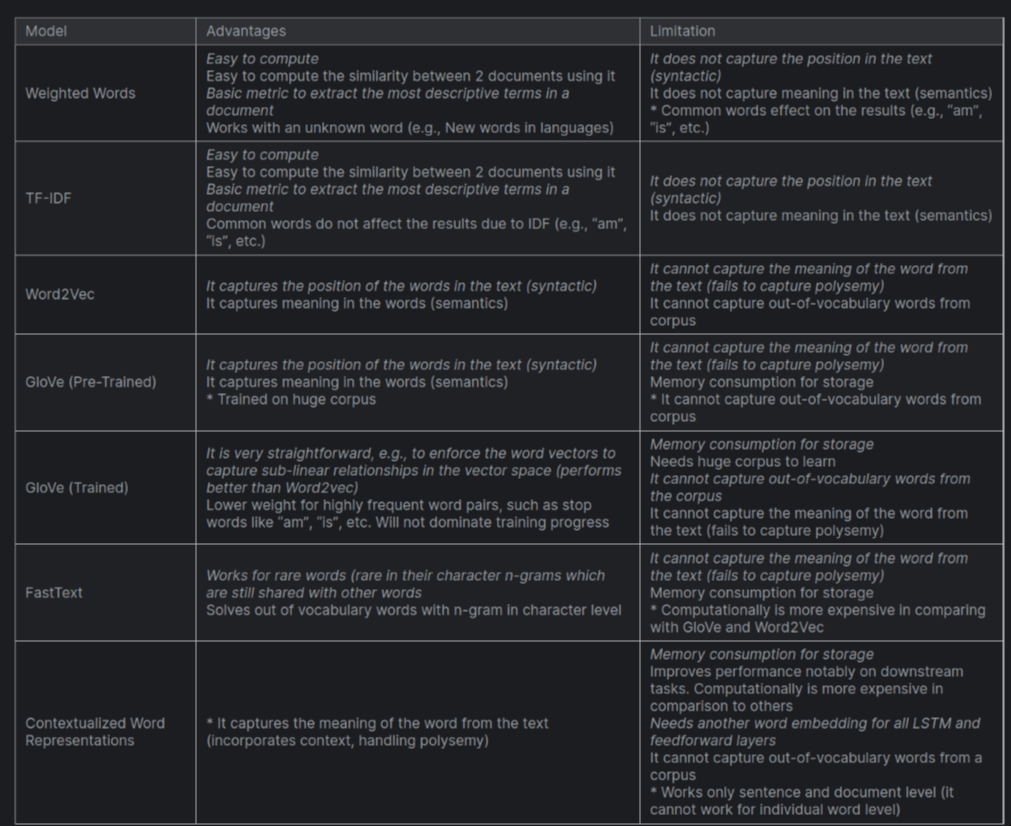



# Other Good Resources

- https://www.kaggle.com/code/vbmokin/nlp-eda-bag-of-words-tf-idf-glove-bert
- https://github.com/hundredblocks/concrete_NLP_tutorial/blob/master/NLP_notebook.ipynb
- https://www.kaggle.com/code/ashishpatel26/beginner-to-intermediate-nlp-tutorial
- https://www.kaggle.com/code/datafan07/disaster-tweets-nlp-eda-bert-with-transformers
- https://www.kaggle.com/code/kksienc/comprehensive-nlp-tutorial-3-bert
- https://www.kaggle.com/code/liananapalkova/simply-about-word2vec
- https://www.kaggle.com/code/sudalairajkumar/getting-started-with-text-preprocessing